# VM.AI Regressors вЂ” Difficulty & Importance Prediction
## Why Separate Regressors?
### The Problem: T5 Struggles with Numeric Fields
Throughout testing, we kept running into the same issue with T5 predicting `difficulty` and `importance`:
- **Semantic mismatch** вЂ” words like `"extreme"` would output `0.5`, while `"not difficult"` would output `0.85`
- **Binary-like outputs** вЂ” the model consistently mapped `"easy"` to `~0.15` and `"hard"` to `~0.85` with nothing in between
- **No per-task context** вЂ” `"hard homework"` and `"hard gym session"` got the same difficulty score even though they're totally different
- **Importance/difficulty confusion** вЂ” couldn't tell that `"hard homework"` might be less physically difficult but more important than `"hard gym session"`
We tried fixing this across multiple parser versions вЂ” changed architectures, restructured data, iterated on prompts. Same problem every time. The issue is fundamental: **T5 is a text-to-text model, not a regressor**. It generates tokens, not numbers. When trained to predict floats like `0.72`, it just learns surface-level token patterns instead of actual numeric relationships.
More training data would help a bit, but it doesn't fix the architectural mismatch.
### The Solution
We split the job: **dedicated XGBoost regressors** on top of **SentenceTransformer embeddings**:
- **SentenceTransformer** (`all-MiniLM-L6-v2`) converts text into 384-dim semantic embeddings that actually understand context and nuance
- **Two independent XGBoostRegressor models** predict `difficulty` and `importance` as real continuous floats in `[0, 1]`
- **Modular design** вЂ” regressors can be updated independently of the T5 parser
## Training Requirements
This notebook is nearly self-contained. It needs:
- **`src/parser/yaml_parser.py`** вЂ” parses YAML datasets into usable format
- **`src/parser/vars.py`** вЂ” shared constants (imported by `yaml_parser.py`)
- **`data/` folder** вЂ” training datasets (`VMAI_REAL_Data.yaml`, `VMAI_REGR_Data.yaml`, etc.)
- **Optional custom datasets** вЂ” extra labeled examples for edge cases or underrepresented task types
## Data Source
Training data comes from `data/VMAI_REAL_Data.yaml` + `data/VMAI_REGR_Data.yaml` вЂ” hand-labeled real user prompts with explicit `difficulty` and `importance` values. Merged into a single CSV for training.
## Train/Test Split
80/20 split with `random_state=42`. Models are evaluated on unseen test data for honest MAE and RВІ.
## Integration
Trained models are saved as `.pkl` files and bundled with the T5 parser on HuggingFace (`vaneaa/vmai-parser`). At runtime, `TaskPlannerPredictor` loads both regressors and applies them during `predict_add()` and `predict_modify()`.
## Interpreting Predictions
**Difficulty (0→1):** trivial → extremely hard  
**Importance (0→1):** optional → critical
### Subjectivity
Difficulty and importance are inherently personal. A task you find "hard" might feel "moderate" to someone else. The model learned your specific labeling patterns. Predictions may not generalize to other users with different thresholds for what counts as "hard" or "important."
### Performance
- **R² ≈ 0.68 (diff) / 0.58 (imp)** — the model captures ~⅔ of your difficulty ratings and ~½ of importance ratings. The remaining ~30-40% reflects noise from personal inconsistency over 500+ labels plus factors the text alone can't convey (energy, deadlines, mood).
- **MAE ≈ 0.10–0.12** — predictions are off by about 10 points on a 0–100 scale.
### When to Trust It
- Clear language with explicit difficulty/importance keywords: *"urgent server fix"*, *"easy stretch"*
- Routine tasks with consistent phrasing across your dataset
### When to Override
- Tasks where context matters more than text: *"finish report"* could be easy or crushing depending on your deadline
- The task feels obviously misjudged — your intuition beats the model

In [1]:
import sys, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from yaml_parser import VMAI_RealDataParser
from sentence_transformers import SentenceTransformer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import RidgeCV
import joblib
from datetime import datetime
import os
warnings.filterwarnings('ignore')

In [2]:
# Consistent across project
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#8b949e",
    "ytick.color": "#8b949e",
    "grid.color": "#21262d",
})

In [45]:
from datetime import datetime, timedelta
import os

def save_fig(name):
    timestamp = (datetime.now() + timedelta(hours=3)).strftime("%Y-%m-%d_%H-%M")
    os.makedirs("plots", exist_ok=True)
    plt.savefig(f"plots/{name}_{timestamp}.png", dpi=150, bbox_inches="tight")
    print(f"  Saved: plots/{name}_{timestamp}.png")


Shape: (1018, 3)

Missing values:
 text          0
difficulty    0
importance    0
dtype: int64

Difficulty stats:
 count    1018.000000
mean        0.482770
std         0.295021
min         0.050000
25%         0.200000
50%         0.400000
75%         0.800000
max         1.000000
Name: difficulty, dtype: float64

Importance stats:
 count    1018.000000
mean        0.477544
std         0.306323
min         0.050000
25%         0.150000
50%         0.500000
75%         0.700000
max         1.000000
Name: importance, dtype: float64
Low difficulty + Low importance:  241
High difficulty + Low importance: 232
High difficulty + High importance:251
Low difficulty + High importance: 294
  Saved: plots/data_2026-05-25_10-26.png


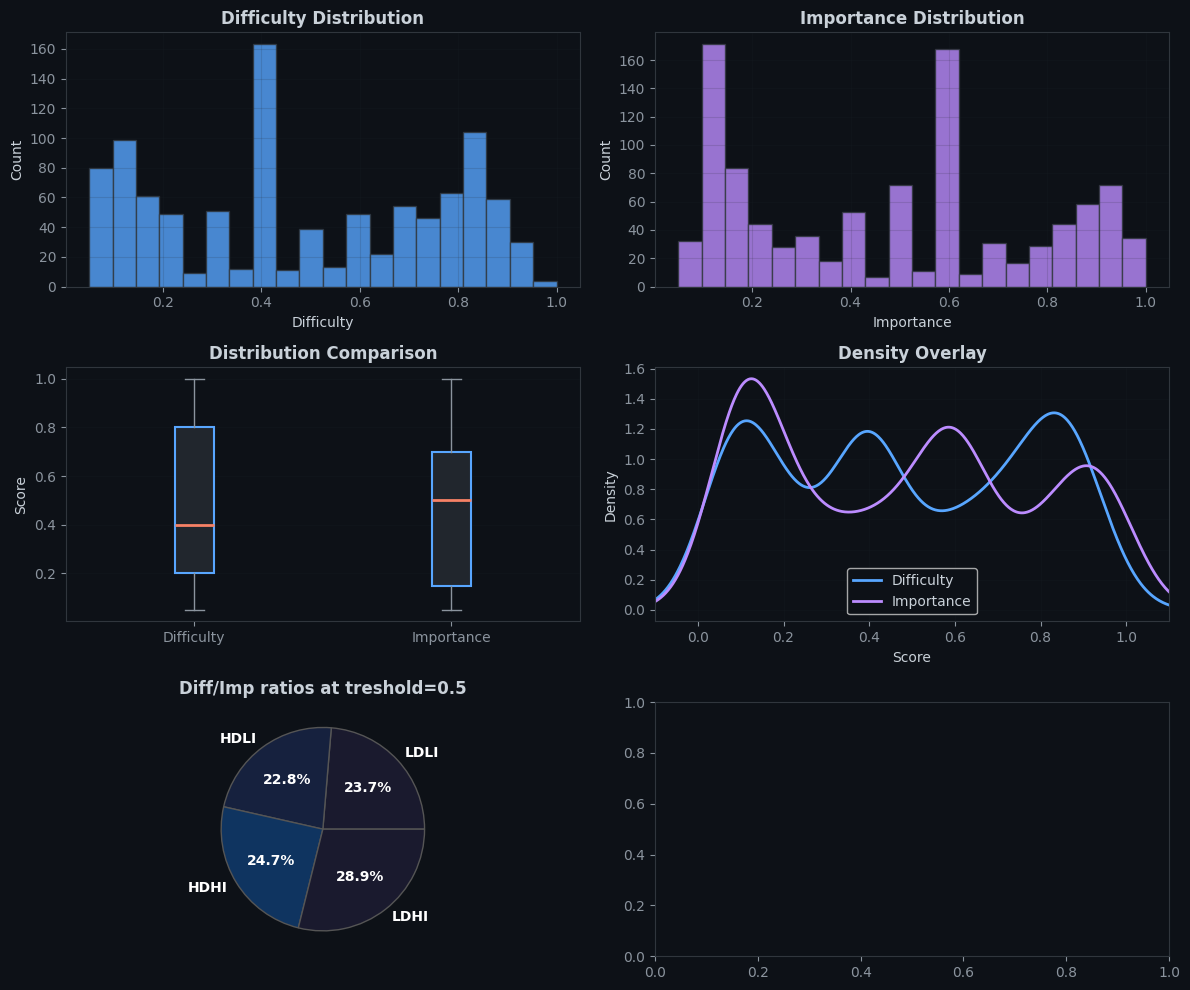

In [46]:
train = pd.read_csv("VMAI_REGR_Data.csv")

print("Shape:", train.shape)
print("\nMissing values:\n", train.isnull().sum())
print("\nDifficulty stats:\n", train["difficulty"].describe())
print("\nImportance stats:\n", train["importance"].describe())

t = 0.5
low_diff_low_imp = ((train["difficulty"] < t) & (train["importance"] < t)).sum()
high_diff_low_imp = ((train["difficulty"] >= t) & (train["importance"] < t)).sum()
high_diff_high_imp = ((train["difficulty"] >= t) & (train["importance"] >= t)).sum()
low_diff_high_imp = ((train["difficulty"] < t) & (train["importance"] >= t)).sum()

print(f"Low difficulty + Low importance:  {low_diff_low_imp}")
print(f"High difficulty + Low importance: {high_diff_low_imp}")
print(f"High difficulty + High importance:{high_diff_high_imp}")
print(f"Low difficulty + High importance: {low_diff_high_imp}")

fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Difficulty distribution
axes[0, 0].hist(train["difficulty"], bins=20, edgecolor="#30363d", alpha=0.8, color="#58a6ff")
axes[0, 0].set_title("Difficulty Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Difficulty")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(True, alpha=0.15)

# Importance distribution
axes[0, 1].hist(train["importance"], bins=20, edgecolor="#30363d", alpha=0.8, color="#bc8cff")
axes[0, 1].set_title("Importance Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Importance")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(True, alpha=0.15)

# Box plot comparison
box_data = [train["difficulty"], train["importance"]]
axes[1, 0].boxplot(box_data, labels=["Difficulty", "Importance"], patch_artist=True,
                    boxprops=dict(facecolor="#21262d", edgecolor="#58a6ff", linewidth=1.5),
                    medianprops=dict(color="#f78166", linewidth=2),
                    whiskerprops=dict(color="#8b949e"),
                    capprops=dict(color="#8b949e"),
                    flierprops=dict(marker="o", markerfacecolor="#f78166", markersize=4))
axes[1, 0].set_title("Distribution Comparison", fontweight="bold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].grid(True, alpha=0.15, axis="y")

# KDE overlay
train["difficulty"].plot.kde(ax=axes[1, 1], label="Difficulty", color="#58a6ff", linewidth=2)
train["importance"].plot.kde(ax=axes[1, 1], label="Importance", color="#bc8cff", linewidth=2)
axes[1, 1].set_title("Density Overlay", fontweight="bold")
axes[1, 1].set_xlabel("Score")
axes[1, 1].set_xlim(-0.1, 1.1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.15)

mono_dark = ['#1a1a2e', '#16213e', '#0f3460', '#1a1a2e']
axes[2, 0].pie(
    [low_diff_low_imp, high_diff_low_imp, high_diff_high_imp, low_diff_high_imp],
    labels=["LDLI", "HDLI", "HDHI", "LDHI"],
    autopct='%1.1f%%',
    colors=mono_dark,
    textprops={'color': 'white', 'fontweight': 'bold'},
    wedgeprops={'edgecolor': '#555555', 'linewidth': 1}
)
axes[2, 0].set_title(f"Diff/Imp ratios at treshold={t}", fontweight="bold")
axes[2, 0].grid(True, alpha=0.15)

plt.tight_layout()
save_fig("data")
plt.show()


In [7]:
X = train["text"].values
y_diff = train["difficulty"].values
y_imp = train["importance"].values

bins = pd.qcut(y_diff, q=5, labels=False, duplicates='drop')
X_train, X_test, y_diff_train, y_diff_test, y_imp_train, y_imp_test, _, test_idx = train_test_split(
    X, y_diff, y_imp, train.index, test_size=0.2, random_state=42, stratify=bins
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Diff train range: {y_diff_train.min():.2f}-{y_diff_train.max():.2f}")
print(f"Diff test range:  {y_diff_test.min():.2f}-{y_diff_test.max():.2f}")

Train: 680 samples
Test:  171 samples
Diff train range: 0.05-1.00
Diff test range:  0.05-0.98


In [ ]:
encoder = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [8]:
encoder = SentenceTransformer('all-mpnet-base-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [9]:
emb_train = encoder.encode(X_train, show_progress_bar=False)
emb_test = encoder.encode(X_test, show_progress_bar=False)
print(f"Train: {emb_train.shape}  Test: {emb_test.shape}")

Train: (680, 768)  Test: (171, 768)


In [10]:
URGENT = {'urgent', 'asap', 'critical', 'deadline', 'important', 'immediately'}
HARD = {'hard', 'difficult', 'complex', 'tough', 'challenging', 'heavy', 'intense'}
EASY = {'easy', 'simple', 'quick', 'light', 'trivial', 'basic', 'gentle'}
TIME = {'minute', 'hour', 'day', 'week', 'month', 'today', 'tomorrow'}
NEGATION = {'not', 'no', 'never', 'without', "n't"}

def _is_negated(words, i):
    for j in range(max(0, i - 2), i):
        if words[j] in NEGATION or words[j].endswith("n't"):
            return True
    return False

def extract_features(texts):
    feats = []
    for t in texts:
        w = t.lower().split()
        n_chars = len(t)
        n_words = len(w)

        urgent_raw = hard_raw = easy_raw = time_raw = 0
        urgent_neg = hard_neg = easy_neg = time_neg = 0
        negation_count = 0

        for i, x in enumerate(w):
            if x in NEGATION or x.endswith("n't"):
                negation_count += 1
            negated = _is_negated(w, i)
            if x in URGENT:
                if negated:
                    urgent_neg += 1
                else:
                    urgent_raw += 1
            if x in HARD:
                if negated:
                    hard_neg += 1
                else:
                    hard_raw += 1
            if x in EASY:
                if negated:
                    easy_neg += 1
                else:
                    easy_raw += 1
            if x in TIME:
                if negated:
                    time_neg += 1
                else:
                    time_raw += 1

        feats.append([
            n_words, n_chars, n_chars / max(n_words, 1),
            t.count('!'),
            sum(1 for c in t if c.isupper()),
            sum(1 for c in t if c.isupper()) / max(n_chars, 1),
            urgent_raw, hard_raw, easy_raw, time_raw,
            urgent_neg, hard_neg, easy_neg, time_neg,
            negation_count,
            int(bool(re.search(r'\d+', t))),
        ])
    return np.array(feats)

feat_train = extract_features(X_train)
feat_test = extract_features(X_test)

X_train_full = np.concatenate([emb_train, feat_train], axis=1)
X_test_full = np.concatenate([emb_test, feat_test], axis=1)

print(f"Embeddings: {emb_train.shape[1]} + Features: {feat_train.shape[1]} = {X_train_full.shape[1]} total")

Embeddings: 768 + Features: 16 = 784 total


In [11]:
def train_models(model_set, name, X, y):
    print(f"Training {name} models")
    for model_name in model_set:
        print(f"  Training '{model_name}'...", end=' ', flush=True)
        model_set[model_name].fit(X, y)
        print("done")

def eval_model(model, X, y, model_name=""):
    pred = np.clip(model.predict(X), 0, 1)
    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    baseline = mean_absolute_error(y, np.full_like(y, np.mean(y)))
    return {
        "model": model_name,
        "MAE": round(mae, 4),
        "R2": round(r2, 4),
        "baseline_MAE": round(baseline, 4),
        "improvement_pct": round((baseline - mae) / baseline * 100, 1),
    }

def eval_models(model_set, name, X, y):
    print(f"Evaluating {name} models")
    results = []
    for model_name in model_set:
        r = eval_model(model_set[model_name], X, y, model_name)
        results.append(r)
        print(f"  {model_name:20s}  MAE={r['MAE']}  R\u00b2={r['R2']}")
    return results

def plot_eval(results, title):
    names = [r["model"] for r in results]
    maes = [r["MAE"] for r in results]
    r2s = [r["R2"] for r in results]
    x = range(len(names))
    plt.figure(figsize=(10, 4))
    plt.bar([i - 0.2 for i in x], maes, 0.4, label='MAE', color='coral')
    plt.bar([i + 0.2 for i in x], r2s, 0.4, label='R\u00b2', color='steelblue')
    plt.xticks(x, names, rotation=45, ha='right')
    plt.title(title)
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_model_diagnostics(model, X, y, title=""):
    pred = np.clip(model.predict(X), 0, 1)
    residuals = y - pred

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(title, fontsize=14)

    axes[0, 0].scatter(y, pred, alpha=0.5, edgecolors='k', linewidth=0.5)
    axes[0, 0].plot([0, 1], [0, 1], 'r--', linewidth=1)
    axes[0, 0].set_xlabel('Actual')
    axes[0, 0].set_ylabel('Predicted')
    axes[0, 0].set_title('Actual vs Predicted')
    axes[0, 0].set_xlim(0, 1); axes[0, 0].set_ylim(0, 1)
    axes[0, 0].axis('equal')

    axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='coral')
    axes[0, 1].axvline(0, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title(f'Residuals  (MAE={mean_absolute_error(y, pred):.4f})')

    axes[1, 0].scatter(pred, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
    axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[1, 0].set_xlabel('Predicted')
    axes[1, 0].set_ylabel('Residual')
    axes[1, 0].set_title('Residuals vs Predicted')

    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_indices = np.digitize(pred, bins) - 1
    mae_per_bin = [np.mean(np.abs(residuals[bin_indices == i])) if np.sum(bin_indices == i) > 0 else 0 for i in range(len(bins) - 1)]
    axes[1, 1].bar(bin_centers, mae_per_bin, width=0.08, edgecolor='black', alpha=0.7, color='steelblue')
    axes[1, 1].set_xlabel('Prediction Bin')
    axes[1, 1].set_ylabel('Mean Absolute Error')
    axes[1, 1].set_title(f'Error by Prediction Range')

    save_fig(title.lower())

    plt.tight_layout()
    plt.show()

    mae = mean_absolute_error(y, pred)
    r2 = r2_score(y, pred)
    print(f"  MAE={mae:.4f}  R²={r2:.4f}")

#### Old versions of this notebook included a hyperparameter tuner for XGBRegressor and these were the results The amount of params in the `param_grid` were enough to get the best parameters (5 different paramter values per paramter and 5 CV + Gridsearch so each combination was tested)


#### With testing tho, it became clear that there were better alternatives (like RigdeCV) and hyperparameter tuning was no longer required

In [12]:
best_params = {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

In [ ]:
MODELS = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=5000),
    "ElasticNet": ElasticNet(max_iter=5000),
    "KNN (k=7)": KNeighborsRegressor(n_neighbors=7),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "SVR (RBF)": SVR(kernel='rbf', gamma='scale'),
    "SVR (linear)": SVR(kernel='linear'),
    "GBoost": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "MLP (64,32)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, random_state=42, verbose=-1),
    "XGB": XGBRegressor(),
    "XGB (tuned)": XGBRegressor(**best_params, random_state=42),
}

diff_models = {k: v for k, v in MODELS.items()}
imp_models = {k: v for k, v in MODELS.items()}

In [13]:
def plot_final_models():
  plot_model_diagnostics(diff_final, X_test_full, y_diff_test, title="Difficulty")
  plot_model_diagnostics(imp_final, X_test_full, y_imp_test, title="Importance")

Training difficulty models
  Training 'Linear Regression'... done
  Training 'Ridge'... done
  Training 'Lasso'... done
  Training 'ElasticNet'... done
  Training 'KNN (k=7)'... done
  Training 'Decision Tree'... done
  Training 'Random Forest'... done
  Training 'Extra Trees'... done
  Training 'SVR (RBF)'... done
  Training 'SVR (linear)'... done
  Training 'GBoost'... done
  Training 'MLP (64,32)'... done
  Training 'LightGBM'... done
  Training 'XGB'... done
  Training 'XGB (tuned)'... done
Evaluating difficulty models
  Linear Regression     MAE=0.3388  RВІ=-1.6232
  Ridge                 MAE=0.1193  RВІ=0.6364
  Lasso                 MAE=0.1971  RВІ=0.0168
  ElasticNet            MAE=0.1935  RВІ=0.0465
  KNN (k=7)             MAE=0.206  RВІ=-0.0391
  Decision Tree         MAE=0.1554  RВІ=0.1675
  Random Forest         MAE=0.1238  RВІ=0.5549
  Extra Trees           MAE=0.1143  RВІ=0.5937
  SVR (RBF)             MAE=0.1869  RВІ=0.1148
  SVR (linear)          MAE=0.1298  RВІ=0.6042


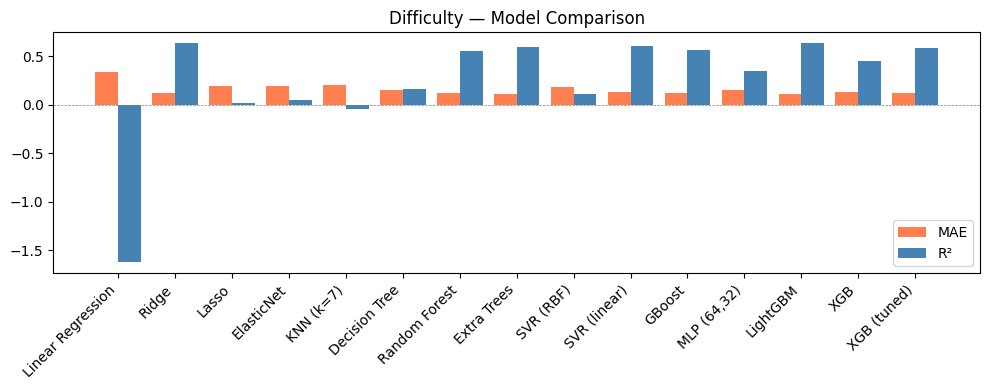

In [ ]:
train_models(diff_models, "difficulty", X_train_full, y_diff_train)
diff_results = eval_models(diff_models, "difficulty", X_test_full, y_diff_test)
plot_eval(diff_results, "Difficulty вЂ” Model Comparison")

Training importance models
  Training 'Linear Regression'... done
  Training 'Ridge'... done
  Training 'Lasso'... done
  Training 'ElasticNet'... done
  Training 'KNN (k=7)'... done
  Training 'Decision Tree'... done
  Training 'Random Forest'... done
  Training 'Extra Trees'... done
  Training 'SVR (RBF)'... done
  Training 'SVR (linear)'... done
  Training 'GBoost'... done
  Training 'MLP (64,32)'... done
  Training 'LightGBM'... done
  Training 'XGB'... done
  Training 'XGB (tuned)'... done
Evaluating importance models
  Linear Regression     MAE=0.3914  RВІ=-2.992
  Ridge                 MAE=0.1274  RВІ=0.5087
  Lasso                 MAE=0.1781  RВІ=0.0004
  ElasticNet            MAE=0.1753  RВІ=0.0758
  KNN (k=7)             MAE=0.1984  RВІ=-0.1501
  Decision Tree         MAE=0.1509  RВІ=0.0805
  Random Forest         MAE=0.148  RВІ=0.3407
  Extra Trees           MAE=0.134  RВІ=0.3761
  SVR (RBF)             MAE=0.1722  RВІ=0.153
  SVR (linear)          MAE=0.1252  RВІ=0.5379
  G

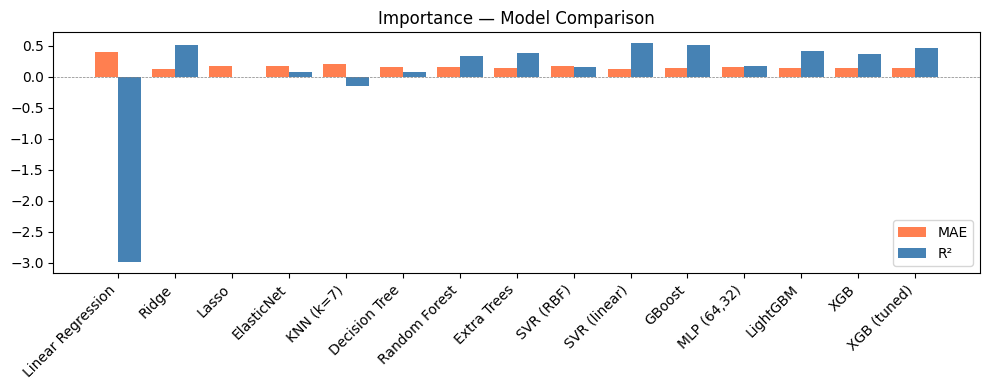

In [ ]:
train_models(imp_models, "importance", X_train_full, y_imp_train)
imp_results = eval_models(imp_models, "importance", X_test_full, y_imp_test)
plot_eval(imp_results, "Importance вЂ” Model Comparison")

# The following cells represent the different models used for for regression and in what order

- XGBRegressor
- Ridge
- RidgeCV

In [14]:
diff_final = XGBRegressor(**best_params, random_state=42, device="cuda")
diff_final.fit(X_train_full, y_diff_train)

imp_final = XGBRegressor(**best_params, random_state=42, device="cuda" )
imp_final.fit(X_train_full, y_imp_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device='cuda', early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=7, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

  Saved: plots/difficulty_2026-05-25_06-56.png


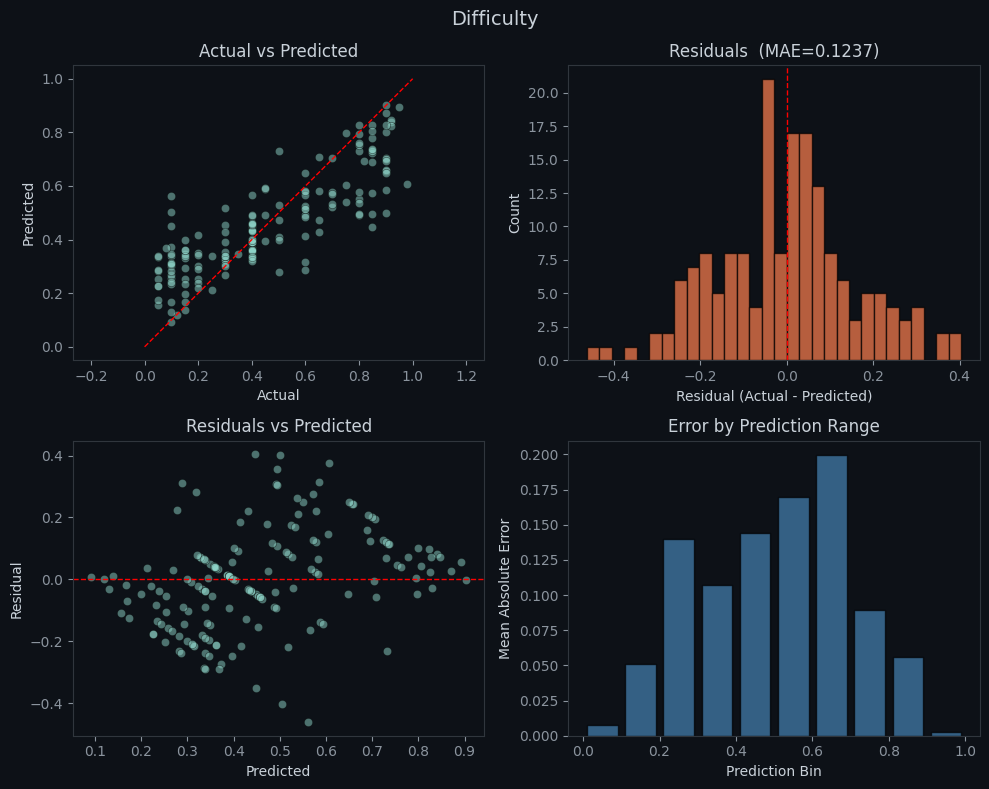

  MAE=0.1237  R²=0.6801
  Saved: plots/importance_2026-05-25_06-56.png


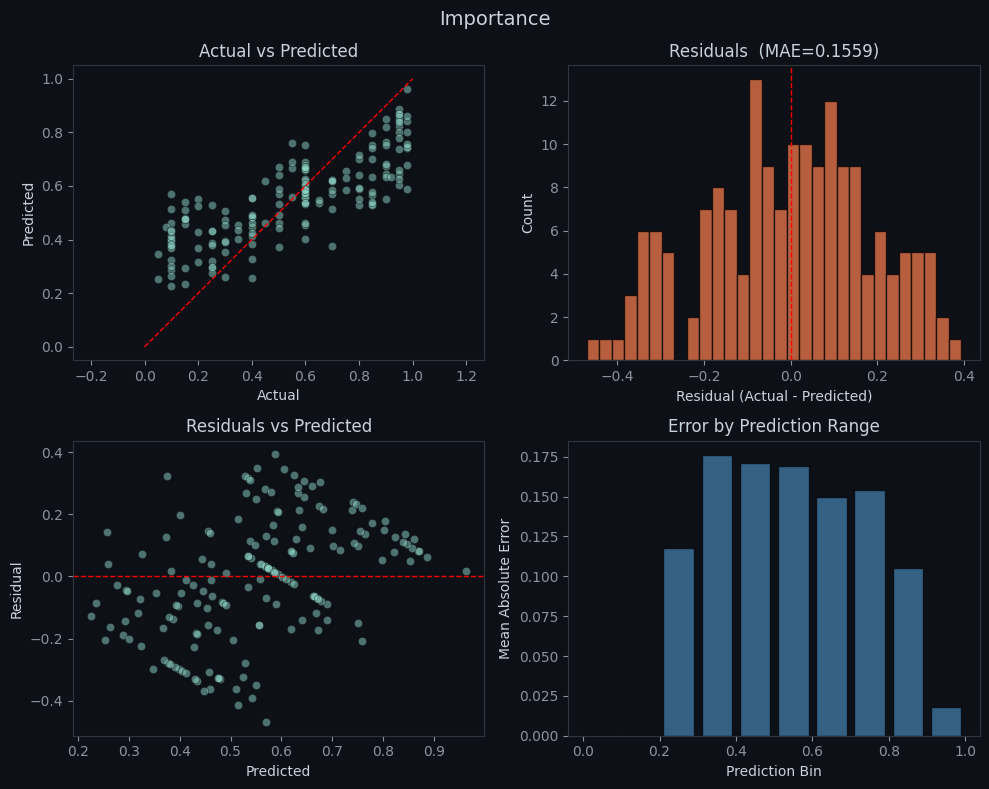

  MAE=0.1559  R²=0.5750


In [15]:
plot_final_models()

In [ ]:
diff_final = Ridge()
diff_final.fit(X_train_full, y_diff_train)

imp_final = Ridge()
imp_final.fit(X_train_full, y_imp_train)

Ridge()

In [ ]:
plot_final_models()

In [16]:
diff_final = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], store_cv_values=True)
diff_final.fit(X_train_full, y_diff_train)
print(f"Best alpha (diff): {diff_final.alpha_}")

imp_final = RidgeCV(alphas=[0.01, 0.1, 1, 10, 100], store_cv_values=True)
imp_final.fit(X_train_full, y_imp_train)
print(f"Best alpha (imp): {imp_final.alpha_}")

Best alpha (diff): 1.0
Best alpha (imp): 1.0


  Saved: plots/difficulty_2026-05-25_06-57.png


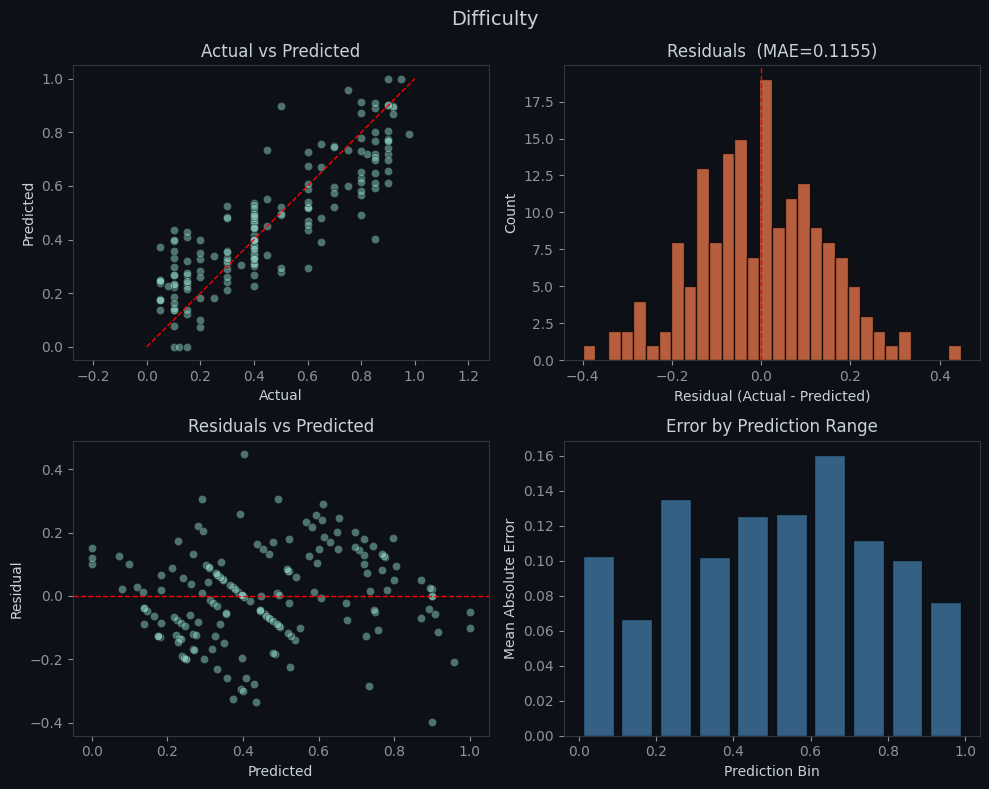

  MAE=0.1155  R²=0.7403
  Saved: plots/importance_2026-05-25_06-57.png


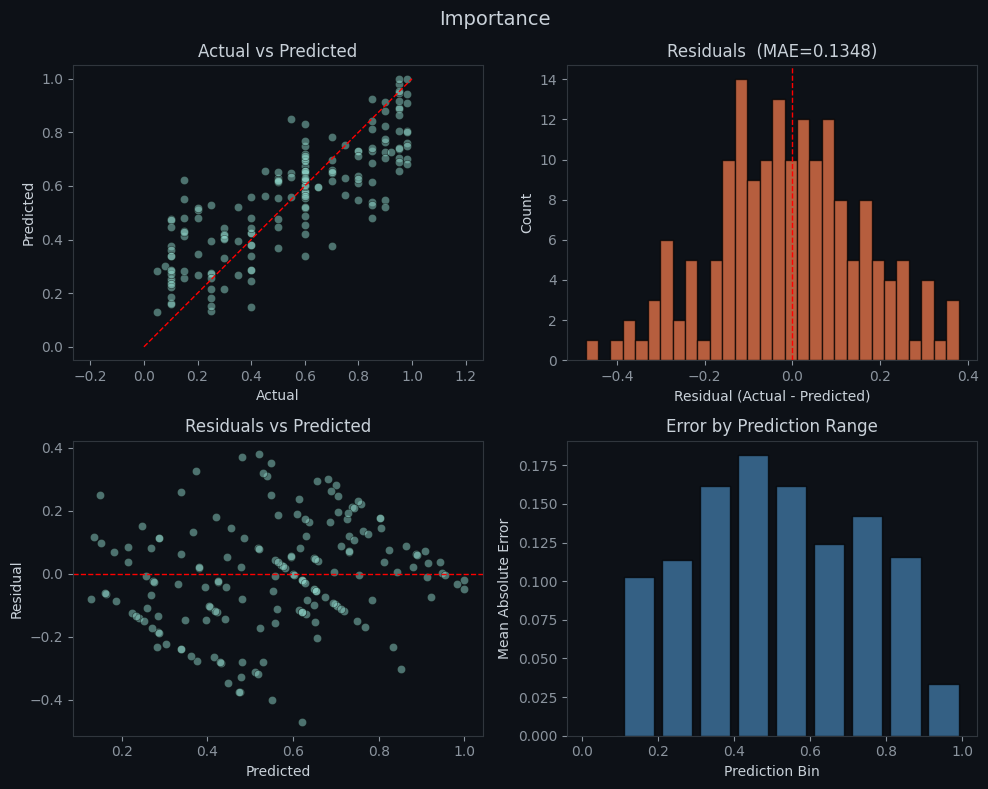

  MAE=0.1348  R²=0.6634


In [17]:
plot_final_models()

In [21]:
diff_final = LinearRegression()
diff_final.fit(X_train_full, y_diff_train)

imp_final = LinearRegression()
imp_final.fit(X_train_full, y_imp_train)

LinearRegression()

  Saved: plots/difficulty_2026-05-25_06-59.png


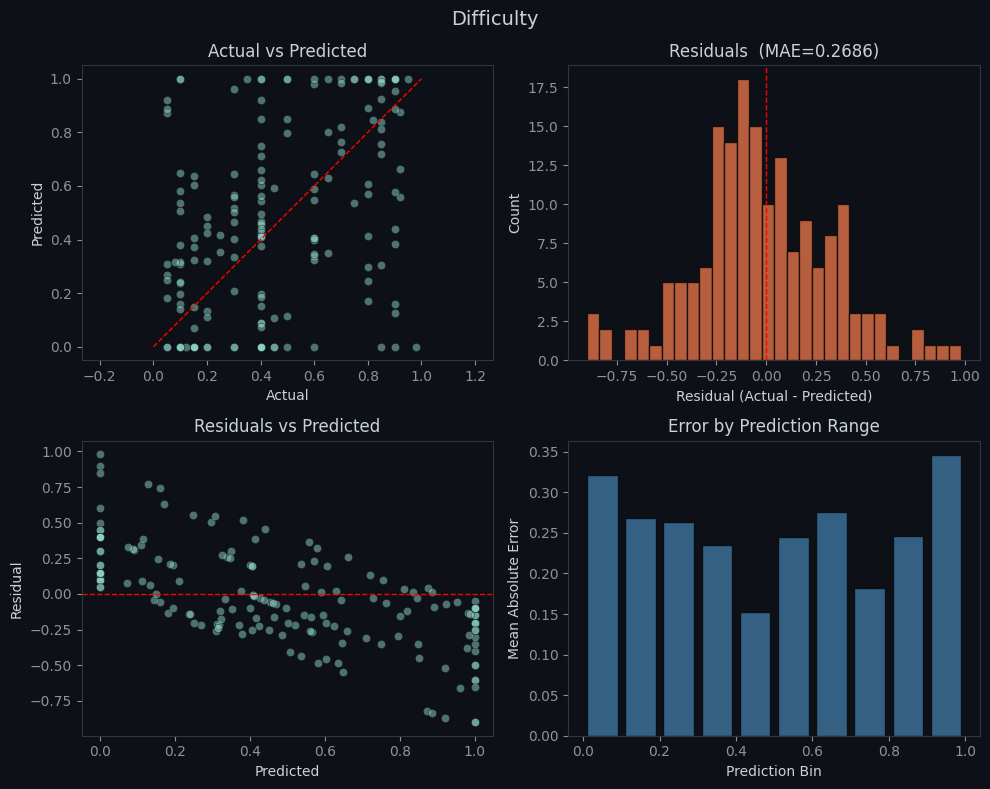

  MAE=0.2686  R²=-0.4828
  Saved: plots/importance_2026-05-25_06-59.png


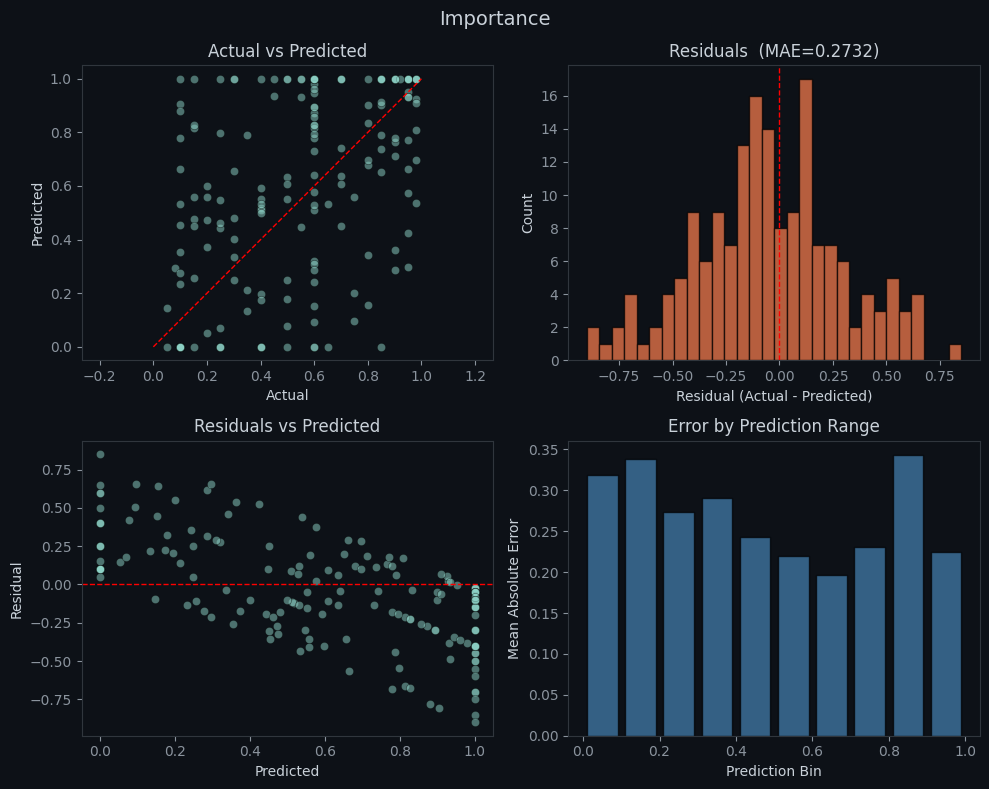

  MAE=0.2732  R²=-0.3920


In [20]:
plot_final_models()

In [ ]:
joblib.dump(diff_final, 'difficulty_regressor.pkl')
joblib.dump(imp_final, 'importance_regressor.pkl')

['importance_regressor.pkl']

In [ ]:
def predict_task(texts, encoder, diff_model, imp_model):
    if isinstance(texts, str):
        texts = [texts]
    emb = encoder.encode(texts, show_progress_bar=False)
    feats = extract_features(texts)
    X = np.concatenate([emb, feats], axis=1)
    d = np.clip(diff_model.predict(X), 0, 1)
    i = np.clip(imp_model.predict(X), 0, 1)
    for t, dv, iv in zip(texts, d, i):
        print(f"{t:<60} diff={dv:.3f}  imp={iv:.3f}")

custom = [
    "finish project report by friday",
    "buy groceries later",
    "urgent server outage fix",
    "read a book before bed",
    "hard workout",
    "easy stretch",
]
predict_task(custom, encoder, diff_final, imp_final)

finish project report by friday                              diff=0.498  imp=0.626
buy groceries later                                          diff=0.150  imp=0.591
urgent server outage fix                                     diff=0.656  imp=0.946
read a book before bed                                       diff=0.211  imp=0.402
hard workout                                                 diff=0.778  imp=0.578
easy stretch                                                 diff=0.080  imp=0.306


In [ ]:
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files
    files.download('difficulty_regressor.pkl')
    files.download('importance_regressor.pkl')
print("Models saved to disk.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models saved to disk.


In [ ]:
import re
MODIFY_PATTERNS = re.compile(r"make it|change|set to|move|push|add |remove|rename|categorize|clear |cancel|mark it|extend|shorten|reschedule", re.I)

test_indices = X_test_index if 'X_test_index' in dir() else train.index[-len(X_test):]
is_mod_test = train.loc[test_indices, 'text'].str.contains(MODIFY_PATTERNS).values

add_mask = ~is_mod_test
mod_mask = is_mod_test

print(f"Add: {add_mask.sum()}  Modify: {mod_mask.sum()}\n")
for target, y_test, model in [("Difficulty", y_diff_test, diff_final), ("Importance", y_imp_test, imp_final)]:
    print(f"=== {target} ===")
    for label, mask in [("Add-only", add_mask), ("Modify-only", mod_mask)]:
        if mask.sum() == 0:
            continue
        pred = np.clip(model.predict(X_test_full[mask]), 0, 1)
        mae = mean_absolute_error(y_test[mask], pred)
        r2 = r2_score(y_test[mask], pred)
        print(f"  {label:15s} ({mask.sum():3d})  MAE={mae:.4f}  R²={r2:.4f}")
    print()

Add: 75  Modify: 36

=== Difficulty ===
  Add-only        ( 75)  MAE=0.1163  R²=0.7128
  Modify-only     ( 36)  MAE=0.1018  R²=0.7422

=== Importance ===
  Add-only        ( 75)  MAE=0.1066  R²=0.7008
  Modify-only     ( 36)  MAE=0.1112  R²=0.6745



In [ ]:
while True:
    text = input(">> ")
    if text in ("exit", "quit"):
        break
    predict_task(text, encoder, diff_final, imp_final)

>> go home
go home                                                      diff=0.289  imp=0.535
>> go home very hard
go home very hard                                            diff=0.558  imp=0.590
>> go home extreme difficulty
go home extreme difficulty                                   diff=0.522  imp=0.648
>> go home very important
go home very important                                       diff=0.296  imp=0.736
>> go home very hard very important
go home very hard very important                             diff=0.545  imp=0.765
>> go home very hard but unimportant
go home very hard but unimportant                            diff=0.543  imp=0.566
>> important
important                                                    diff=0.326  imp=0.649
>> unimportant
unimportant                                                  diff=0.193  imp=0.297
>> go home unimportant
go home unimportant                                          diff=0.248  imp=0.522
>> go home
go home                       

KeyboardInterrupt: Interrupted by user